In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

# 读取Excel文件中（此数据已经完成初步筛选）
file_path = r'E:\dataname.xlsx'
data = pd.read_excel(file_path, sheet_name=1)

data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

displacement_cols = data.columns[0:4]  # 位移列（第1-4列）
factor_cols = data.columns[4:]         # 影响因素列（第5列开始）


scalers = {}
for col in displacement_cols:
    scaler = MinMaxScaler(feature_range=(0, 1))
    data[[col]] = scaler.fit_transform(data[[col]])
    scalers[col] = scaler

for col in factor_cols:
    scaler = MinMaxScaler(feature_range=(0, 1))
    data[[col]] = scaler.fit_transform(data[[col]])
    scalers[col] = scaler

# 划分训练集和测试集
train_size = int(len(data) * 0.8)
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]


Epoch 1/40
19/19 [==============================] - 4s 35ms/step - loss: 0.0528 - val_loss: 0.0029
Epoch 2/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0232 - val_loss: 0.0069
Epoch 3/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0161 - val_loss: 0.0034
Epoch 4/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0144 - val_loss: 0.0022
Epoch 5/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0117 - val_loss: 0.0021
Epoch 6/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0103 - val_loss: 0.0019
Epoch 7/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0093 - val_loss: 0.0018
Epoch 8/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0079 - val_loss: 0.0015
Epoch 9/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0064 - val_loss: 0.0015
Epoch 10/40
19/19 [==============================] - 0s 6ms/step - loss: 0.0068 - val_loss: 0.0017
Epoch 11/40
19/19 

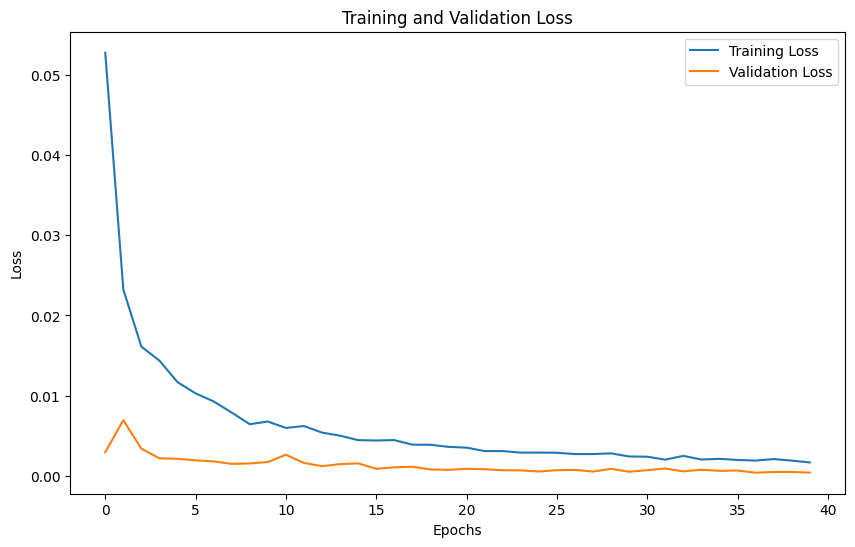

In [10]:
# 定义时间步长
time_steps = 2

def create_sequences(data, time_steps, target_index):
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data.iloc[i:i + time_steps].values)  # 使用历史位移和影响因素
        y.append(data.iloc[i + time_steps, target_index])  # 预测第一个监测点的位移
    return np.array(X), np.array(y)

# 使用第一个监测点的位移为预测目标
target_index = 0  
X_train, y_train = create_sequences(train_data, time_steps, target_index)
X_test, y_test = create_sequences(test_data, time_steps, target_index)

# 构建GRU模型
model = Sequential([
    GRU(30, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(25, return_sequences=False),
    Dropout(0.2),
    Dense(15),
    Dense(1)
])


model.compile(optimizer='adam', loss='mean_squared_error')

history = model.fit(X_train, y_train, epochs=40, batch_size=64, validation_data=(X_test, y_test), verbose=1)

# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

In [11]:
# 进行预测
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# 将预测结果逆归一化
target_col = displacement_cols[0]  # 第一个监测点位移是目标
train_predict = scalers[target_col].inverse_transform(train_predict)
test_predict = scalers[target_col].inverse_transform(test_predict)

# 将真实值逆归一化
y_train_actual = scalers[target_col].inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scalers[target_col].inverse_transform(y_test.reshape(-1, 1))

# 计算训练集和测试集的 R² 和 RMSE
train_r2 = r2_score(y_train_actual, train_predict)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_r2 = r2_score(y_test_actual, test_predict)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

# 输出结果
print(f"训练集 R²: {train_r2:.4f}")
print(f"训练集 RMSE: {train_rmse:.4f}")
print(f"测试集 R²: {test_r2:.4f}")
print(f"测试集 RMSE: {test_rmse:.4f}")

10/10 [==============================] - 0s 2ms/step
训练集 R²: 0.9925
训练集 RMSE: 1.1685
测试集 R²: 0.9002
测试集 RMSE: 1.3066


In [ ]:
import pandas as pd

# 创建 DataFrame 来保存预测结果
results_df = pd.DataFrame({
    'Date': data.index[-(len(y_train_actual) + len(y_test_actual)):],  # 使用日期索引
    'Train_True': list(y_train_actual.flatten()) + [None] * len(y_test_actual),  # 训练集真实值
    'Train_Predict': list(train_predict.flatten()) + [None] * len(y_test_actual),  # 训练集预测值
    'Test_True': [None] * len(y_train_actual) + list(y_test_actual.flatten()),  # 测试集真实值
    'Test_Predict': [None] * len(y_train_actual) + list(test_predict.flatten())  # 测试集预测值
})

# 指定输出文件路径和 sheet 名称
output_file_path = file_path  
sheet_name = 'GRU_Predictions'

with pd.ExcelWriter(output_file_path, mode='a', engine='openpyxl') as writer:
    results_df.to_excel(writer, sheet_name=sheet_name, index=False)

print("预测结果已成功导出到Excel文件的新sheet中。")